# Testing Area for Nico 

## Description
**TASK**

Implement a regression tree algorithm and a random forest algorithm (based on 
the implemented regression tree algorithm) for predicting numeric values– You can find various implementations for these algorithms. However, we can also apply our own ideas for splitting of instances
+ We should implement these algorithms from scratch (not using any part of existing code)
+ We can use existing code/functions for general parts like: Code for reading the input and testing the algorithm (cross- validation, performance metrics for regression...) 

**COMPARISON**

Compare the implemented techniques with the existing implementations of regression trees/random forest and one other existing regression techniques (we may use the default parameters for the existing techniques) 

+ Experiment with at least three configurations (number of trees, ...) for random 
forest
+ Using at least two performance metrics for comparison
+ Applying cross-validation

***Conclusions***
+ How efficient are our algorithms?
+ Performance of our algorithms?
+ Other findings


## Code section

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

from typing import Literal, Dict, Any, Self
from numpy.typing import ArrayLike

import logging

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.setLevel(logging.INFO)

In [2]:
DecisionTreeRegressor

sklearn.tree._classes.DecisionTreeRegressor

The principle of building a Regression Tree follows the same approach as the creation of a Classification Tree.

We search for the feature which splits the target feature values most purely, divide the dataset along the values of this descriptive feature and repeat this process for each of the sub datasets until we accomplish a stopping criteria. If we accomplish a stopping criteria, we grow a leaf node.

Most notable difference is when to stop:
If we now consider the property of our new continuously scaled target feature we mention that the third stopping criteria can no longer be used since the target feature values can now take on an infinite number of different values. Consequently, it is most likely that we will not find pure target feature values until there is only one instance left in the dataset.

Long story short, there is in general nothing like pure target feature values.

To address this issue, we will introduce an early stopping criteria that returns the average value of the target feature values left in the dataset if the number of instances in the dataset is e.g. <= 5.

In [2]:
class RegressionTreeNico():
    '''
    Custom implementation of a regression decision tree for 
    184.702 Machine Learning (VU 3,0) 2025W

    This class builds a regression tree from scratch and supports both
    categorical and continuous features. It uses variance/MSE reduction
    as the splitting criterion. It also supports recursive tree growth with
    configurable stopping criteria (minimum instances per leaf, maximum depth).

    '''    

    def __init__(self) -> None:
        pass

    def _calc_MSE(self, Y_true: ArrayLike, Y_pred: ArrayLike) -> np.float64:
        '''
        Calculates mean squared error

        Returns:
            MSE of given features
        
        '''
        return np.square(np.subtract(Y_true, Y_pred)).mean()

    def _calc_variance_cat_features(self, data: ArrayLike, target_name: str, which_feature_name: str) -> np.float64:
        '''
        Used to calculate the variance of categorical features to decide which feature to use for the next leaf via minimum variance!

        Parameters
        ----------
        data : ArrayLike
            The data set in which we want to calculate the variance for a given feature
        target_name: str
            Name of the target feature
        which_feature_name: str
            Name of the feature for which we want to calculate the variance.

        Returns
        -------
        np.float64
            The (weighted) variance of the feature in the given data
        '''

        feature_values = np.unique(data[which_feature_name])
        feature_variance = 0

        for value in feature_values:
            subset = data[data[which_feature_name] == value].reset_index()

            # In case we have only one appearance of a value, then we have to make sure it makes 0 instead of inf because of the division / (N - 1)
            if len(subset) <= 1:
                subset_var = 0.0
            else:
                # standard in np.var is divided by N instead of N - 1!
                subset_var = (len(subset)/len(data)) * np.var(subset[target_name], ddof=1)

            feature_variance += subset_var
        
        return feature_variance
    
    def _calc_variance_cont_features(self, data: ArrayLike, target_name: str, which_feature_name: str) -> np.float64:
        '''
        Used to calculate the variance of continous features to decide which feature to use for the next leaf via minimum variance!
        
        Parameters
        ----------
        data : ArrayLike
            The data set in which we want to calculate the variance for a given feature
        target_name: str
            Name of the target feature
        which_feature_name: str
            Name of the feature for which we want to calculate the variance.

        Returns
        -------
        np.float64
            The (weighted) variance of the feature in the given data
        '''   

        # initialize weighted mse
        best_weighted_mse = np.inf
        best_threshold = np.inf
                    
        # sort the data by the feature
        data = data.sort_values(by=which_feature_name)

        # compute the mse at current node
        current_yhat = np.mean(data[target_name].mean())
        current_mse = self._calc_MSE(data[target_name], current_yhat)
        current_mse = np.round(current_mse, 3)

        # iterate over all rows of the SORTED data
        for i in range(1, len(data)):
            logger.info(data)
            logger.info(which_feature_name)
            logger.info(f"{data.iloc[i][which_feature_name]}, {data.iloc[i-1][which_feature_name]}")
            # compute average of two consecutive rows to have some threshold start 
            split_val = (data.iloc[i][which_feature_name] + data.iloc[i-1][which_feature_name]) / 2
            split_val = np.round(split_val, 3)

            #print(i, split_val)

            # split the data into the two sides
            left_branch = data[data[which_feature_name]<=split_val]
            right_branch = data[data[which_feature_name]>split_val]

            # compute the MSE of both sides
            left_yhat = np.mean(left_branch[target_name]) 
            left_yhat = np.round(left_yhat, 3)
            left_mse = self._calc_MSE(left_branch[target_name], left_yhat) 
            left_mse = np.round(left_mse, 3)

            right_yhat = np.mean(right_branch[target_name]) 
            right_yhat = np.round(right_yhat, 3)
            right_mse = self._calc_MSE(right_branch[target_name], right_yhat) 
            right_mse = np.round(right_mse, 3)

            # compute weighted MSE
            weighted_mse = ((len(left_branch) * left_mse) + (len(right_branch) * right_mse))/len(data)
            weighted_mse = np.round(weighted_mse, 3)

            # update bestbest_weighted_mse
            if weighted_mse <= best_weighted_mse:
                best_weighted_mse = weighted_mse
                best_threshold = split_val

        return best_weighted_mse, best_threshold

    def _calc_entropy(self, target_column: str) -> np.float64:
        '''
        Calculate the entropy of a target column
       
        Parameters
        ----------
        target_column : ArrayLike
            The target column of which we want to calculate the entropy

        Returns
        -------
        np.float64
            The entropy of the given target column    
        '''

        elements, counts = np.unique(target_column, return_counts = True)

        entropy = np.sum([(-counts[i]/np.sum(counts)) * np.log2(counts[i] / np.sum(counts)) for i in range(len(elements))])
        
        return entropy
    
    def _calc_information_gain(self, data: ArrayLike, target_name:str, which_feature_name: str) -> np.float64:
        '''
        Calculate the information gain based on an attribute (with its weighted entropy!) and the target variable entropy
        
        Parameters
        ----------
        data : ArrayLike
            The data set in which we want to calculate the information gain for a given feature
        target_name: str
            Name of the target feature
        which_feature_name: str
            Name of the feature for which we want to calculate the information gain.

        Returns
        -------
        np.float64
            The infomation gain of the given column    
        '''
        target_entropy = self._calc_entropy(data[target_name])

        vals, counts = np.unique(data[which_feature_name], return_counts=True)

        # Calculate the WEIGHTED entropy
        weighted_entropy = np.sum([(counts[i] / np.sum(counts)) * self._calc_entropy(data[data[which_feature_name]==vals[i]].dropna()[target_name]) for i in range(len(vals))])
    
        # Calculate the information gain
        information_gain = target_entropy - weighted_entropy
        
        return information_gain

    def _find_best_split(self, data: pd.DataFrame, target_name: str, categorical_features:list = []) -> Dict:
        best_feature = None
        best_threshold = None
        best_variance = np.inf
        is_continuous = False

        for feature_name in data.columns:
            logger.info(f"passed categorical_features: {categorical_features}")
            if feature_name == target_name:
                continue

            elif feature_name in categorical_features:
                logger.info(f"feature {feature_name} entered categorical processing step")
                variance = self._calc_variance_cat_features(data, target_name, feature_name)
                
                # if improvement: overwrite values
                if variance <= best_variance:
                    best_feature = feature_name
                    best_threshold = None
                    best_variance = variance
                    is_continuous = False
            
            else:
                logger.info(f"feature {feature_name} entered continous processing step")

                variance, threshold = self._calc_variance_cont_features(data, target_name, feature_name)
                                
                # if improvement: overwrite values
                if variance <= best_variance:
                    best_feature = feature_name
                    best_threshold = threshold
                    best_variance = variance
                    is_continuous = True
        
        return best_feature, best_threshold, best_variance, is_continuous

    def _Classfier(
            self, 
            data: pd.DataFrame, 
            target_name: str, 
            min_instances: int = 1, 
            categorical_features: list = [], 
            max_depth: int = None, 
            features: list = None,
            depth: int = 0) -> dict[str, Any]:
        '''
        Recursive tree building algorithm.

        Parameters
        ----------
        data : pd.DataFrame
            Subset of the dataset at the current node.
        target_name : str
            Name of the target column
        min_instances : int, optional
            Minimum number of samples required to allow further splitting, else mean is taken.
        categorical_features : list, optional (but actually necessary in case of such)
            List of feature names that represent categorical features
        max_depth : int, optional
            Maximum depth of the tree. If None, the tree grows until min_instances is reached
        features : list, optional
            List of (remaining) features available for splitting
        depth : int, optional
            Depth of the recursion. Used internally

        Returns
        -------
        dict[str, Any] or float
            A nested dictionary representing the tree structure. 
            "Any" will be another such dictionary or a float (= mean target value) if the leaf node is reached

        
        '''
        # Stopping criterion for the recurrsion if we require some minimum value for the size/length of a sub dataset
        if len(data) <= min_instances:
            return np.mean(data[target_name])
    
        # If the dataset has reached the wished for tdepth, return the mean target feature value of the remaining dataset as before
        elif max_depth != None and depth >= max_depth:
            return np.mean(data[target_name])

        # Now this is the actual "tree growing" part
        else:
            # get the best split
            best_feature, best_threshold, best_variance, is_continuous = self._find_best_split(data, target_name, categorical_features)

            features = list(data.columns)
            features.remove(target_name)

            # Small fallback in case of no best value found
            if best_feature == None:
                logger.info(f"No best feature to split on found. \nDepth: {depth} \nFeatures left: {features} ")
                return np.mean(data[target_name])

            if is_continuous:
                # build the branching for continous variables
                left_branch = data[data[best_feature] <= best_threshold]
                right_branch = data[data[best_feature] > best_threshold]
                
                ''' Structure for continous feature split:
                {
                    "feature": "X1",
                    "threshold": 400,
                    "left": { subtree(s) for X <= 400 or value in case we reached conditions (ie leaf node) above},
                    "right": { subtree(s) for X > 400 or value in case we reached conditions (ie leaf node) above}
                }   
                '''

                return {
                    "feature": best_feature,
                    "threshold": best_threshold,
                    "left": self._Classfier(data=left_branch, 
                                            target_name=target_name, 
                                            categorical_features=categorical_features,
                                            min_instances=min_instances, 
                                            max_depth=max_depth, 
                                            depth= depth+1),
                    "right": self._Classfier(data=right_branch, 
                                             target_name=target_name, 
                                             categorical_features=categorical_features,
                                             min_instances=min_instances, 
                                             max_depth=max_depth, 
                                             depth= depth+1)
                }
            
            else:
                branches = {}
                for val in np.unique(data[best_feature]):
                    subset = data[data[best_feature] == val]
                    branches[val] = self._Classfier(data=subset, 
                                                    target_name=target_name, 
                                                    categorical_features=categorical_features,
                                                    min_instances=min_instances, 
                                                    max_depth=max_depth, 
                                                    depth= depth+1)
                
                ''' Structure for non-continous feature split:
                {
                    "feature": "categoryXY",
                    "branches": { 
                        "X": subtree(s) for value "X" of feature categoryXY,
                        "Y": subtree(s) for value "Y" of feature categoryXY
                    }
                }   
                '''
                
                return {
                    "feature": best_feature,
                    "branches": branches
                }
    
    def fit(self, 
            data: pd.DataFrame, 
            target_name: str, 
            min_instances: int = 1,
            max_depth: int = None,
            categorical_features: list = []) -> Self:
            
        '''
        Creates ("fits") the regression tree to the given dataset.

        Parameters
        ----------
        data : pd.DataFrame
            Training dataset containing features AND the target
        target_name : str
            Name of the target column
        min_instances : int, optional
            Minimum number of samples required to allow further splitting, else mean is taken.
        max_depth : int, optional
            Maximum depth of the tree. If None, the tree grows until min_instances is reached
        categorical_features : list, optional (but actually necessary in case of such)
            List of feature names that represent categorical features

        Returns
        -------
        Self
            Stores the learned tree in `self.tree_` of the initialized instance of this class.
        '''

        self.target_name = target_name
        self.categorical_features = categorical_features
        self.max_depth = max_depth
        self.min_instances = min_instances
        self.tree_ = self._Classfier(
            data, target_name, categorical_features=categorical_features, min_instances=min_instances, max_depth=max_depth
        )
        return self

    def _predict_row(self, X_pred: ArrayLike, tree:dict, features:list, categorical_features: list = []):
        logger.info(f"Entering _predict_row with (sub)tree: {tree}")
        logger.info(f"X_pred row: {X_pred}")
        logger.info(f"categorical_features passed to _predict_row: {categorical_features}")
        
        if tree["feature"] in features:
            feature = tree["feature"]
            logger.info(f"Checking for feature: {feature}\ncategorical features passed: {categorical_features}")

            if feature in categorical_features:
                ''' sample structure
                {
                "feature": "categoryXY",
                "branches": { 
                    "X": subtree(s) for value "X" of feature categoryXY,
                    "Y": subtree(s) for value "Y" of feature categoryXY
                } 
                '''
                result = tree["branches"][X_pred[feature]]
            else:
                ''' sample structure
                {
                "feature": "X1",
                "threshold": 400,
                "left": { subtree(s) for X <= 400 or value in case we reached conditions (ie leaf node) above},
                "right": { subtree(s) for X > 400 or value in case we reached conditions (ie leaf node) above}
                }   
                '''
                threshold = tree["threshold"]
                logger.info(f"feature: {feature} // feature_value: {X_pred[feature]} // threshold: {threshold}")
                result = tree["left"] if X_pred[feature] <= threshold else tree["right"]
            
            logger.info(f"result: {result}")
            
            # continue if not a leaf
            if isinstance(result, dict):
                return self._predict_row(X_pred, result, features, categorical_features) #.drop(feature)
            # if we get a value then return and "break" the recurssion
            else:
                if isinstance(result, (np.float64, float)):
                    return result
                else:
                    logging.error(f"result is not of type float, type: {type(result)}")
                    raise ValueError(f"result is not of type float, type: {type(result)}")

    def predict(self, X_pred: ArrayLike, categorical_features: list = []) -> np.float64:
        '''


        Parameters
        -------

        Returns
        -------


        '''
        ''' Structure for continous feature split:
        {
        "feature": "X1",
        "threshold": 400,
        "left": { subtree(s) for X <= 400 or value in case we reached conditions (ie leaf node) above},
        "right": { subtree(s) for X > 400 or value in case we reached conditions (ie leaf node) above}
        }   
        '''
        ''' Structure for non-continous feature split:
        {
            "feature": "categoryXY",
            "branches": { 
                "X": subtree(s) for value "X" of feature categoryXY,
                "Y": subtree(s) for value "X" of feature categoryXY
            }
        }   
        '''
        features = X_pred.columns

        result = X_pred.apply(self._predict_row, args=(self.tree_, features, categorical_features), axis=1)


        return result

In [ ]:
# "test" data

# continous example
np.random.seed(0)

a, b, c = 1, 2, 3
n = 100 
x = np.linspace(-10, 10, n)  # feature values from -10 to 10
noise = np.random.normal(0, 10, n)  # some random noise
y = a * x**2 + b * x + c + noise  # quadratic equation with noise

df_continous = pd.DataFrame({'X': x, 'y': y})

# categorical examples
df_small = pd.DataFrame({'Number_of_Bedrooms':[2,2,4,1,3,1,4,2],'Price_of_Sale':[100000,120000,250000,80000,220000,170000,500000,75000]})

df = pd.read_csv("day.csv",usecols=['season','holiday','weekday','weathersit','cnt'])
df_example = df.sample(frac=0.012)

In [8]:
testTree = RegressionTreeNico()
treee = testTree.fit(df_example, categorical_features=["season", "holiday", "weekday", "weathersit"], max_depth = 10, target_name="cnt")
y_pred_custom = treee.predict(df_example.drop("cnt", axis=1), categorical_features=["season", "holiday", "weekday", "weathersit"])

data_encoded = pd.get_dummies(df_example[["season", "holiday", "weekday", "weathersit"]], drop_first=True)
sk_tree = DecisionTreeRegressor(random_state=42)
sk_tree.fit(data_encoded, df_example["cnt"])
y_pred = sk_tree.predict(df_example.drop("cnt", axis=1))

print(y_pred_custom)
print(y_pred)

2025-12-02 10:57:47,446 - INFO - passed categorical_features: ['season', 'holiday', 'weekday', 'weathersit']
2025-12-02 10:57:47,447 - INFO - feature season entered categorical processing step
2025-12-02 10:57:47,484 - INFO - passed categorical_features: ['season', 'holiday', 'weekday', 'weathersit']
2025-12-02 10:57:47,485 - INFO - feature holiday entered categorical processing step
2025-12-02 10:57:47,490 - INFO - passed categorical_features: ['season', 'holiday', 'weekday', 'weathersit']
2025-12-02 10:57:47,496 - INFO - feature weekday entered categorical processing step
2025-12-02 10:57:47,504 - INFO - passed categorical_features: ['season', 'holiday', 'weekday', 'weathersit']
2025-12-02 10:57:47,505 - INFO - feature weathersit entered categorical processing step
2025-12-02 10:57:47,506 - INFO - passed categorical_features: ['season', 'holiday', 'weekday', 'weathersit']
2025-12-02 10:57:47,507 - INFO - passed categorical_features: ['season', 'holiday', 'weekday', 'weathersit']
2025

608    4984.0
350    2739.0
299    2659.0
726    2114.0
253    4984.0
230    4984.0
269    4120.0
14     1248.0
202    4984.0
dtype: float64
[5368.5 2739.  2659.  2114.  5046.  4153.  4120.  1248.  5368.5]


In [5]:
df_example

,season,holiday,weekday,weathersit,cnt
608,3,0,5,1,7350
350,4,0,6,2,2739
299,4,0,4,2,2659
726,1,0,4,2,2114
253,3,0,0,1,5046
230,3,0,5,2,4153
269,4,0,2,2,4120
14,1,0,6,2,1248
202,3,0,5,1,3387


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt


data_encoded = pd.get_dummies(data[["X1", "X2"]], drop_first=True)

# --- Step 3: Fit sklearn tree ---
sk_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
sk_tree.fit(data_encoded, data["y"])
# Toy dataset testing out both
data = pd.DataFrame({
    "X1": [1, 2, 3, 4, 5, 6],          # continuous
    "X2": ["A", "A", "B", "B", "A", "B"],  # categorical
    "y":  [1.1, 1.9, 3.0, 3.9, 5.1, 6.2]   # target
})

tree = RegressionTreeNico()
tree.fit(data, target_name="y", categorical_features=["X2"], max_depth=3)
y_pred_custom = tree.predict(data.drop(columns=["y"]), categorical_features=["X2"])


2025-12-02 10:39:28,506 - INFO - passed categorical_features: ['X2']
2025-12-02 10:39:28,508 - INFO - feature X1 entered continous processing step
2025-12-02 10:39:28,514 - INFO -    X1 X2    y
0   1  A  1.1
1   2  A  1.9
2   3  B  3.0
3   4  B  3.9
4   5  A  5.1
5   6  B  6.2
2025-12-02 10:39:28,522 - INFO - X1
2025-12-02 10:39:28,524 - INFO - 2, 1
2025-12-02 10:39:28,527 - INFO -    X1 X2    y
0   1  A  1.1
1   2  A  1.9
2   3  B  3.0
3   4  B  3.9
4   5  A  5.1
5   6  B  6.2
2025-12-02 10:39:28,530 - INFO - X1
2025-12-02 10:39:28,531 - INFO - 3, 2
2025-12-02 10:39:28,533 - INFO -    X1 X2    y
0   1  A  1.1
1   2  A  1.9
2   3  B  3.0
3   4  B  3.9
4   5  A  5.1
5   6  B  6.2
2025-12-02 10:39:28,536 - INFO - X1
2025-12-02 10:39:28,537 - INFO - 4, 3
2025-12-02 10:39:28,538 - INFO -    X1 X2    y
0   1  A  1.1
1   2  A  1.9
2   3  B  3.0
3   4  B  3.9
4   5  A  5.1
5   6  B  6.2
2025-12-02 10:39:28,539 - INFO - X1
2025-12-02 10:39:28,539 - INFO - 5, 4
2025-12-02 10:39:28,540 - INFO - 

In [70]:
print("Tree structure:", tree.tree_)
print("Custom predictions:", y_pred_custom.values)
print(data["y"])

Tree structure: {'feature': 'X1', 'threshold': np.float64(3.5), 'left': {'feature': 'X1', 'threshold': np.float64(2.5), 'left': {'feature': 'X1', 'threshold': np.float64(1.5), 'left': np.float64(1.1), 'right': np.float64(1.9)}, 'right': np.float64(3.0)}, 'right': {'feature': 'X1', 'threshold': np.float64(4.5), 'left': np.float64(3.9), 'right': {'feature': 'X2', 'branches': {'A': np.float64(5.1), 'B': np.float64(6.2)}}}}
Custom predictions: [1.1 1.9 3.  3.9 5.1 6.2]
0    1.1
1    1.9
2    3.0
3    3.9
4    5.1
5    6.2
Name: y, dtype: float64


In [ ]:
def print_tree(tree: dict, depth: int = 0):
    """
    Recursively prints the custom regression tree structure in a readable format.
    """
    indent = "  " * depth

    # Continuous split
    if "threshold" in tree:
        print(f"{indent}Feature: {tree['feature']} <= {tree['threshold']}")
        if isinstance(tree["left"], dict):
            print(f"{indent}--> Left:")
            print_tree(tree["left"], depth + 1)
        else:
            print(f"{indent}--> Left leaf: {tree['left']:.3f}")

        print(f"{indent}Feature: {tree['feature']} > {tree['threshold']}")
        if isinstance(tree["right"], dict):
            print(f"{indent}--> Right:")
            print_tree(tree["right"], depth + 1)
        else:
            print(f"{indent}--> Right leaf: {tree['right']:.3f}")

    # Categorical split
    elif "branches" in tree:
        print(f"{indent}Feature: {tree['feature']} (categorical)")
        for val, branch in tree["branches"].items():
            if isinstance(branch, dict):
                print(f"{indent}--> Value {val}:")
                print_tree(branch, depth + 1)
            else:
                print(f"{indent}--> Value {val} leaf: {branch:.3f}")


Feature: X1 <= 3.5
--> Left:
  Feature: X1 <= 2.5
  --> Left leaf: 1.500
  Feature: X1 > 2.5
  --> Right leaf: 3.000
Feature: X1 > 3.5
--> Right:
  Feature: X1 <= 4.5
  --> Left leaf: 3.900
  Feature: X1 > 4.5
  --> Right leaf: 5.650


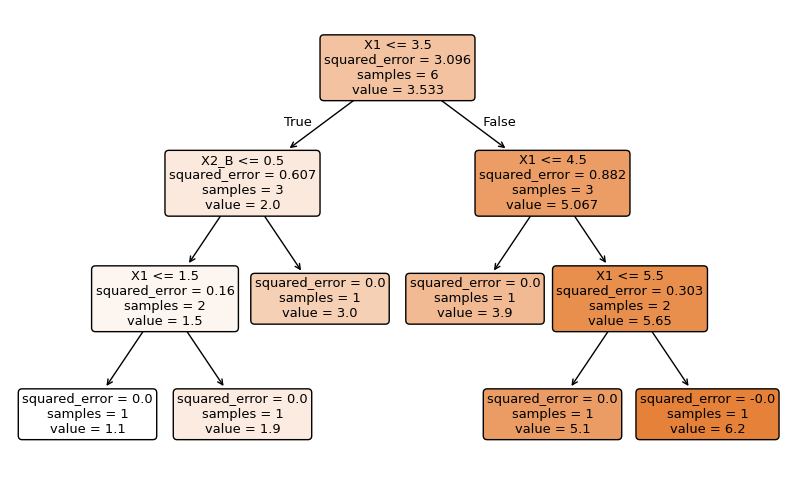

Feature: X1 <= 3.5
--> Left:
  Feature: X1 <= 2.5
  --> Left:
    Feature: X1 <= 1.5
    --> Left leaf: 1.100
    Feature: X1 > 1.5
    --> Right leaf: 1.900
  Feature: X1 > 2.5
  --> Right leaf: 3.000
Feature: X1 > 3.5
--> Right:
  Feature: X1 <= 4.5
  --> Left leaf: 3.900
  Feature: X1 > 4.5
  --> Right:
    Feature: X2 (categorical)
    --> Value A leaf: 5.100
    --> Value B leaf: 6.200


In [71]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# --- Step 1: Tiny dataset ---
data = pd.DataFrame({
    "X1": [1, 2, 3, 4, 5, 6],          # continuous
    "X2": ["A", "A", "B", "B", "A", "B"],  # categorical
    "y":  [1.1, 1.9, 3.0, 3.9, 5.1, 6.2]   # target
})

# --- Step 2: Encode categorical for sklearn ---
data_encoded = pd.get_dummies(data[["X1", "X2"]], drop_first=True)

# --- Step 3: Fit sklearn tree ---
sk_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
sk_tree.fit(data_encoded, data["y"])

# --- Step 4: Visualize the tree ---
plt.figure(figsize=(10,6))
plot_tree(sk_tree, feature_names=data_encoded.columns, filled=True, rounded=True)
plt.show()
print_tree(tree.tree_)